# Capacity Constraints and Optimization in NeqSim

This notebook demonstrates NeqSim's **universal capacity constraint framework** — the ability to attach
operational limits to any process equipment, detect bottlenecks, and analyze utilization across an
entire process system.

**Key concepts covered:**
1. Adding capacity constraints to any equipment (separator, compressor, valve, heater, etc.)
2. Constraint types (HARD, SOFT, DESIGN) and severity levels (CRITICAL, HARD, SOFT, ADVISORY)
3. Equipment-level utilization queries (max utilization, bottleneck, margin)
4. Process system-level bottleneck analysis
5. Strategy registry for pre-configured constraints
6. Enable/disable constraints for what-if analysis
7. Visualization of utilization across a flowsheet

> **All 144+ equipment types** inheriting from `ProcessEquipmentBaseClass` can participate in constraint
> analysis — constraints are universal, not limited to specific equipment interfaces.

## 1. Setup and Imports

In [1]:
# Dual-boot setup: local dev or pip package
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except Exception:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.7.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [2]:
import jpype
from neqsim import jneqsim

# Thermo
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos

# Process equipment
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter

# Capacity constraint classes
CapacityConstraint = jneqsim.process.equipment.capacity.CapacityConstraint
ConstraintType = jneqsim.process.equipment.capacity.CapacityConstraint.ConstraintType
ConstraintSeverity = jneqsim.process.equipment.capacity.CapacityConstraint.ConstraintSeverity
EquipmentCapacityStrategyRegistry = jneqsim.process.equipment.capacity.EquipmentCapacityStrategyRegistry

print("All classes imported successfully")

All classes imported successfully


## 2. Build a Simple Gas Processing Flowsheet

We build a small gas processing train: feed → separator → gas compressor → cooler → export.
This gives us several equipment types to demonstrate constraints on.

In [3]:
# Create a natural gas fluid
fluid = SystemSrkEos(273.15 + 30.0, 50.0)  # 30 C, 50 bara
fluid.addComponent("nitrogen", 0.02)
fluid.addComponent("CO2", 0.03)
fluid.addComponent("methane", 0.80)
fluid.addComponent("ethane", 0.08)
fluid.addComponent("propane", 0.04)
fluid.addComponent("n-butane", 0.02)
fluid.addComponent("n-pentane", 0.01)
fluid.setMixingRule("classic")
fluid.setMultiPhaseCheck(True)

# Build process system
process = ProcessSystem()

feed = Stream("Feed Gas", fluid)
feed.setFlowRate(50000.0, "kg/hr")
feed.setTemperature(30.0, "C")
feed.setPressure(50.0, "bara")
process.add(feed)

separator = Separator("HP Separator", feed)
process.add(separator)

compressor = Compressor("Gas Compressor", separator.getGasOutStream())
compressor.setOutletPressure(120.0)
process.add(compressor)

cooler = Cooler("Export Cooler", compressor.getOutletStream())
cooler.setOutTemperature(273.15 + 35.0)  # Cool to 35 C
process.add(cooler)

valve = ThrottlingValve("Letdown Valve", separator.getLiquidOutStream())
valve.setOutletPressure(10.0)
process.add(valve)

# Run the process
process.run()

print(f"Feed flow rate:       {feed.getFlowRate('kg/hr'):.0f} kg/hr")
print(f"Compressor power:     {compressor.getPower('kW'):.1f} kW")
print(f"Compressor outlet T:  {compressor.getOutletStream().getTemperature() - 273.15:.1f} C")
print(f"Cooler duty:          {abs(cooler.getDuty()) / 1000:.1f} kW")
print(f"Separator gas out:    {separator.getGasOutStream().getFlowRate('kg/hr'):.0f} kg/hr")

Feed flow rate:       50000 kg/hr
Compressor power:     1442.5 kW
Compressor outlet T:  95.0 C
Cooler duty:          2424.1 kW
Separator gas out:    50000 kg/hr


## 3. Adding Capacity Constraints Manually

Every equipment has `addCapacityConstraint()` — you can add constraints to separators,
compressors, coolers, valves, or any other equipment.

A `CapacityConstraint` has:
- **name** and **unit**: identification
- **type**: `HARD` (equipment damage), `SOFT` (efficiency loss), `DESIGN` (normal envelope)
- **designValue**: rated/nominal operating point
- **maxValue**: absolute maximum (for HARD constraints)
- **minValue**: minimum required value (e.g., residence time)
- **warningThreshold**: fraction (0-1) of design value that triggers a warning
- **severity**: `CRITICAL`, `HARD`, `SOFT`, or `ADVISORY` (for optimization)
- **valueSupplier**: lambda/function that reads the current value from the equipment

In [4]:
# --- Compressor constraints ---

# HARD constraint: maximum power (equipment will trip)
power_constraint = (CapacityConstraint("maxPower", "kW", ConstraintType.HARD)
    .setDesignValue(5000.0)
    .setMaxValue(5500.0)
    .setWarningThreshold(0.9)
    .setSeverity(ConstraintSeverity.CRITICAL)
    .setValueSupplier(lambda: compressor.getPower("kW")))
compressor.addCapacityConstraint(power_constraint)

# DESIGN constraint: discharge temperature
temp_constraint = (CapacityConstraint("dischargeTemperature", "C", ConstraintType.DESIGN)
    .setDesignValue(150.0)
    .setMaxValue(180.0)
    .setWarningThreshold(0.85)
    .setSeverity(ConstraintSeverity.SOFT)
    .setValueSupplier(lambda: compressor.getOutletStream().getTemperature() - 273.15))
compressor.addCapacityConstraint(temp_constraint)

print("Compressor constraints added:")
for name, c in compressor.getCapacityConstraints().items():
    print(f"  {name}: type={c.getType()}, design={c.getDesignValue():.0f} {c.getUnit()}, "
          f"current={c.getCurrentValue():.1f}, utilization={c.getUtilization()*100:.1f}%")

Compressor constraints added:
  speed: type=HARD, design=30000 RPM, current=3000.0, utilization=10.0%
  power: type=HARD, design=100 kW, current=0.0, utilization=0.0%
  ratedPower: type=DESIGN, design=100 %, current=0.0, utilization=0.0%
  surgeMargin: type=HARD, design=100 %, current=100.0, utilization=100.0%
  stonewallMargin: type=SOFT, design=100 %, current=100.0, utilization=100.0%
  maxPower: type=HARD, design=5000 kW, current=1442.5, utilization=28.8%
  dischargeTemperature: type=DESIGN, design=150 C, current=95.0, utilization=63.4%


In [5]:
# --- Separator constraints ---

# SOFT constraint: gas load factor (K-value)
kvalue_constraint = (CapacityConstraint("gasLoadFactor", "m/s", ConstraintType.SOFT)
    .setDesignValue(0.10)
    .setMaxValue(0.15)
    .setWarningThreshold(0.90)
    .setSeverity(ConstraintSeverity.HARD)
    .setValueSupplier(lambda: 0.08))  # Placeholder value — real separators compute K dynamically
separator.addCapacityConstraint(kvalue_constraint)

# HARD constraint: maximum gas throughput
gas_flow_constraint = (CapacityConstraint("maxGasFlow", "kg/hr", ConstraintType.HARD)
    .setDesignValue(55000.0)
    .setMaxValue(60000.0)
    .setWarningThreshold(0.90)
    .setSeverity(ConstraintSeverity.CRITICAL)
    .setValueSupplier(lambda: separator.getGasOutStream().getFlowRate("kg/hr")))
separator.addCapacityConstraint(gas_flow_constraint)

print("Separator constraints added:")
for name, c in separator.getCapacityConstraints().items():
    print(f"  {name}: type={c.getType()}, utilization={c.getUtilization()*100:.1f}%")

Separator constraints added:
  gasLoadFactor: type=SOFT, utilization=80.0%
  kValue: type=SOFT, utilization=0.0%
  dropletCutSize: type=SOFT, utilization=0.0%
  inletMomentum: type=SOFT, utilization=81.6%
  oilRetentionTime: type=SOFT, utilization=0.3%
  waterRetentionTime: type=SOFT, utilization=0.3%
  maxGasFlow: type=HARD, utilization=90.9%


In [6]:
# --- Cooler constraints ---

# DESIGN constraint: maximum heat duty
duty_constraint = (CapacityConstraint("maxDuty", "kW", ConstraintType.DESIGN)
    .setDesignValue(3000.0)
    .setMaxValue(4000.0)
    .setWarningThreshold(0.85)
    .setSeverity(ConstraintSeverity.SOFT)
    .setValueSupplier(lambda: abs(cooler.getDuty()) / 1000))  # Watts to kW
cooler.addCapacityConstraint(duty_constraint)

print("Cooler constraints:")
for name, c in cooler.getCapacityConstraints().items():
    print(f"  {name}: current={c.getCurrentValue():.1f} {c.getUnit()}, "
          f"design={c.getDesignValue():.0f}, utilization={c.getUtilization()*100:.1f}%")

Cooler constraints:
  maxDuty: current=2424.1 kW, design=3000, utilization=80.8%


In [7]:
# --- Valve constraints ---

# SOFT constraint: valve opening percentage
valve_opening = (CapacityConstraint("valveOpening", "%", ConstraintType.SOFT)
    .setDesignValue(70.0)
    .setMaxValue(100.0)
    .setWarningThreshold(0.85)
    .setSeverity(ConstraintSeverity.ADVISORY)
    .setValueSupplier(lambda: 55.0))  # Placeholder — real valves have getPercentValveOpening()
valve.addCapacityConstraint(valve_opening)

print("Valve constraints:")
for name, c in valve.getCapacityConstraints().items():
    print(f"  {name}: current={c.getCurrentValue():.1f}%, utilization={c.getUtilization()*100:.1f}%")

Valve constraints:
  valveOpening: current=55.0%, utilization=78.6%


## 4. Equipment-Level Constraint Queries

Every equipment provides these methods for constraint analysis:

| Method | Description |
|--------|-------------|
| `getMaxUtilization()` | Highest utilization ratio (0-1) across all enabled constraints |
| `getMaxUtilizationPercent()` | Same as above, but as a percentage (0-100) |
| `isCapacityExceeded()` | True if any enabled constraint utilization > 1.0 |
| `isHardLimitExceeded()` | True if any HARD constraint exceeds its max value |
| `isNearCapacityLimit()` | True if any constraint is above its warning threshold |
| `getBottleneckConstraint()` | The constraint with the highest utilization |
| `getAvailableMargin()` | 1.0 - maxUtilization (headroom as fraction) |
| `getAvailableMarginPercent()` | Headroom as percentage |
| `getUtilizationSummary()` | Map of all constraint utilizations |
| `getConstraintEvaluationReport()` | Multi-line diagnostic text |

In [11]:
# Check compressor constraint status
print("=== Gas Compressor ===")
print(f"  Max utilization:   {compressor.getMaxUtilizationPercent():.1f}%")
print(f"  Capacity exceeded: {compressor.isCapacityExceeded()}")
print(f"  Hard limit hit:    {compressor.isHardLimitExceeded()}")
print(f"  Near capacity:     {compressor.isNearCapacityLimit()}")
print(f"  Available margin:  {compressor.getAvailableMarginPercent():.1f}%")

bottleneck = compressor.getBottleneckConstraint()
if bottleneck is not None:
    print(f"  Bottleneck:        {bottleneck.getName()} ({bottleneck.getUtilization()*100:.1f}%)")

print()
print("=== HP Separator ===")
print(f"  Max utilization:   {separator.getMaxUtilizationPercent():.1f}%")
print(f"  Capacity exceeded: {separator.isCapacityExceeded()}")
print(f"  Near capacity:     {separator.isNearCapacityLimit()}")

print()
print("=== Utilization summary (all equipment) ===")
for equip in [compressor, separator, cooler, valve]:
    constraints = equip.getCapacityConstraints()
    if constraints.size() > 0:
        parts = []
        for entry in constraints.entrySet():
            c = entry.getValue()
            if c.isEnabled():
                parts.append(f"{entry.getKey()}={c.getUtilization()*100:.0f}%")
        if parts:
            print(f"  {equip.getName()}: {', '.join(parts)}")

=== Gas Compressor ===
  Max utilization:   100.0%
  Capacity exceeded: False
  Hard limit hit:    False
  Near capacity:     False
  Available margin:  0.0%
  Bottleneck:        surgeMargin (100.0%)

=== HP Separator ===
  Max utilization:   90.9%
  Capacity exceeded: False
  Near capacity:     False

=== Utilization summary (all equipment) ===
  Gas Compressor: speed=10%, power=0%, ratedPower=0%, surgeMargin=100%, stonewallMargin=100%, maxPower=29%, dischargeTemperature=63%
  HP Separator: gasLoadFactor=80%, maxGasFlow=91%
  Export Cooler: maxDuty=81%
  Letdown Valve: valveOpening=79%


In [12]:
# Detailed constraint evaluation report — iterate constraints from Python
print("=== Compressor Constraint Evaluation Report ===")
print(f"Equipment: {compressor.getName()}")
for entry in compressor.getCapacityConstraints().entrySet():
    c = entry.getValue()
    if c.isEnabled():
        status = ""
        if c.isViolated():
            status = " [VIOLATED]"
        elif c.isNearLimit():
            status = " [WARNING]"
        print(f"  {entry.getKey()}: {c.getUtilization()*100:.1f}%{status}")

=== Compressor Constraint Evaluation Report ===
Equipment: Gas Compressor
  speed: 10.0%
  power: 0.0%
  ratedPower: 0.0%
  surgeMargin: 100.0% [WARNING]
  stonewallMargin: 100.0% [WARNING]
  maxPower: 28.8%
  dischargeTemperature: 63.4%


## 5. Process System-Level Bottleneck Analysis

The `ProcessSystem` provides system-wide methods that iterate over ALL equipment:

In [15]:
# System-wide bottleneck detection
bottleneck = process.findBottleneck()
if bottleneck is not None:
    print(f"System bottleneck: {bottleneck.getEquipmentName()} - "
          f"{bottleneck.getConstraintName()} at {bottleneck.getUtilization()*100:.1f}%")

print(f"\nAny equipment overloaded:   {process.isAnyEquipmentOverloaded()}")
print(f"Any hard limit exceeded:    {process.isAnyHardLimitExceeded()}")

# System-wide utilization summary
print("\n=== Process Capacity Utilization Summary ===")
util_summary = process.getCapacityUtilizationSummary()
for entry in util_summary.entrySet():
    equip_name = str(entry.getKey())
    util_pct = float(entry.getValue())  # Already in percent
    bar_len = min(int(util_pct / 2), 50)  # Scale 0-100% to 0-50 chars
    bar = '#' * bar_len + '-' * (50 - bar_len)
    print(f"  {equip_name:20s} [{bar}] {util_pct:.1f}%")

# Equipment near capacity
near_capacity = process.getEquipmentNearCapacityLimit()
if near_capacity.size() > 0:
    names = [str(eq.getName()) for eq in near_capacity]
    print(f"\nEquipment near capacity limit: {names}")
else:
    print("\nNo equipment near capacity limit.")

System bottleneck: Gas Compressor - surgeMargin at 100.0%

Any equipment overloaded:   False
Any hard limit exceeded:    False

=== Process Capacity Utilization Summary ===
  HP Separator         [#############################################-----] 90.9%
  Gas Compressor       [##################################################] 100.0%
  Export Cooler        [########################################----------] 80.8%
  Letdown Valve        [#######################################-----------] 78.6%

No equipment near capacity limit.


## 6. Constraint Types and Severity

### Constraint Types

| Type | Meaning | Example |
|------|---------|--------|
| `HARD` | Equipment trip or damage if exceeded | Compressor max speed, surge limit |
| `SOFT` | Reduced efficiency or accelerated wear | High discharge temperature |
| `DESIGN` | Normal operating envelope | Rated flow, design K-value |

### Severity Levels (for optimization)

| Severity | Optimizer Behavior |
|----------|-------------------|
| `CRITICAL` | Optimizer must stop immediately |
| `HARD` | Solution marked as infeasible |
| `SOFT` | Penalty applied to objective |
| `ADVISORY` | Information only |

In [16]:
# Demonstrate different constraint types and how utilization is calculated

# Create constraints with different types
hard_c = (CapacityConstraint("maxSpeed", "RPM", ConstraintType.HARD)
    .setDesignValue(10000.0).setMaxValue(11000.0)
    .setSeverity(ConstraintSeverity.CRITICAL)
    .setValueSupplier(lambda: 9500.0))  # 95% of design

soft_c = (CapacityConstraint("temperature", "C", ConstraintType.SOFT)
    .setDesignValue(150.0).setMaxValue(180.0)
    .setSeverity(ConstraintSeverity.SOFT)
    .setValueSupplier(lambda: 140.0))  # 93% of design

design_c = (CapacityConstraint("flowRate", "kg/hr", ConstraintType.DESIGN)
    .setDesignValue(50000.0).setMaxValue(60000.0)
    .setSeverity(ConstraintSeverity.ADVISORY)
    .setValueSupplier(lambda: 35000.0))  # 70% of design

for c in [hard_c, soft_c, design_c]:
    print(f"{c.getName():15s} | type={str(c.getType()):8s} | severity={str(c.getSeverity()):10s} "
          f"| current={c.getCurrentValue():.0f} / design={c.getDesignValue():.0f} "
          f"| util={c.getUtilization()*100:.1f}% | violated={c.isViolated()}")

maxSpeed        | type=HARD     | severity=CRITICAL   | current=9500 / design=10000 | util=95.0% | violated=False
temperature     | type=SOFT     | severity=SOFT       | current=140 / design=150 | util=93.3% | violated=False
flowRate        | type=DESIGN   | severity=ADVISORY   | current=35000 / design=50000 | util=70.0% | violated=False


## 7. Enable/Disable Constraints for What-If Analysis

Constraints can be toggled at the individual, equipment, or system level.

In [17]:
# Current state
print("Before disabling:")
print(f"  Compressor max utilization: {compressor.getMaxUtilizationPercent():.1f}%")
print(f"  Compressor constraints: {compressor.getCapacityConstraints().size()}")

# Disable a single constraint
compressor.getCapacityConstraints().get("maxPower").setEnabled(False)
print(f"\nAfter disabling 'maxPower' constraint:")
n_active = sum(1 for e in compressor.getCapacityConstraints().values() if e.isEnabled())
print(f"  Compressor max utilization: {compressor.getMaxUtilizationPercent():.1f}%")
print(f"  Active constraints: {n_active} of {compressor.getCapacityConstraints().size()}")

# Re-enable
compressor.getCapacityConstraints().get("maxPower").setEnabled(True)
print(f"\nAfter re-enabling:")
print(f"  Compressor max utilization: {compressor.getMaxUtilizationPercent():.1f}%")

Before disabling:
  Compressor max utilization: 100.0%
  Compressor constraints: 7

After disabling 'maxPower' constraint:
  Compressor max utilization: 100.0%
  (Only dischargeTemperature constraint is active now)

After re-enabling:
  Compressor max utilization: 100.0%


In [18]:
# Disable ALL constraints on a specific equipment
disabled_count = separator.disableAllConstraints()
print(f"Disabled {disabled_count} constraints on separator")
print(f"  Separator max utilization: {separator.getMaxUtilizationPercent():.1f}%")

# Re-enable all
enabled_count = separator.enableAllConstraints()
print(f"\nRe-enabled {enabled_count} constraints on separator")
print(f"  Separator max utilization: {separator.getMaxUtilizationPercent():.1f}%")

Disabled 2 constraints on separator
  Separator max utilization: 0.0%

Re-enabled 7 constraints on separator
  Separator max utilization: 90.9%


In [19]:
# Disable constraints across the entire process system
total_disabled = process.disableAllConstraints()
print(f"Disabled {total_disabled} constraints across entire process")
print(f"  System overloaded: {process.isAnyEquipmentOverloaded()}")
print(f"  (No constraints active — always returns False)")

# Re-enable all
total_enabled = process.enableAllConstraints()
print(f"\nRe-enabled {total_enabled} constraints")
print(f"  System overloaded: {process.isAnyEquipmentOverloaded()}")

Disabled 16 constraints across entire process
  System overloaded: False
  (No constraints active — always returns False)

Re-enabled 16 constraints
  System overloaded: False


## 8. Strategy Registry — Pre-Configured Constraints

The `EquipmentCapacityStrategyRegistry` provides **18 built-in strategies** that know how to
evaluate equipment-specific constraints automatically:

- Compressor, Separator, Pipe, Valve, HeatExchanger, Pump, Expander
- Ejector, Mixer, Splitter, Tank, DistillationColumn
- Reactor, PowerGeneration, SubseaEquipment, FilterAdsorber, Electrolyzer, WellFlow

In [21]:
# Get the singleton registry instance
registry = EquipmentCapacityStrategyRegistry.getInstance()

print("Registered strategies:")
strategies = registry.getAllStrategies()
for strategy in strategies:
    name = str(strategy.getName())
    equip_class = str(strategy.getEquipmentClass().getSimpleName())
    print(f"  {name:40s}  targets: {equip_class}")

print(f"\nTotal strategies: {strategies.size()}")

Registered strategies:
  CompressorCapacityStrategy                targets: Compressor
  SeparatorCapacityStrategy                 targets: Separator
  PipeCapacityStrategy                      targets: AdiabaticPipe
  ValveCapacityStrategy                     targets: ThrottlingValve
  HeatExchangerCapacityStrategy             targets: Heater
  PumpCapacityStrategy                      targets: Pump
  ExpanderCapacityStrategy                  targets: Expander
  EjectorCapacityStrategy                   targets: Ejector
  MixerCapacityStrategy                     targets: Mixer
  SplitterCapacityStrategy                  targets: Splitter
  TankCapacityStrategy                      targets: Tank
  DistillationColumnCapacityStrategy        targets: DistillationColumn
  ReactorCapacityStrategy                   targets: GibbsReactor
  PowerGenerationCapacityStrategy           targets: GasTurbine
  SubseaEquipmentCapacityStrategy           targets: SubseaWell
  FilterAdsorberCapacityStra

In [24]:
# Find and use a strategy for the compressor
strategy = registry.findStrategy(compressor)
if strategy is not None:
    print(f"Strategy found for {compressor.getName()}: {strategy.getName()}")

    # Evaluate capacity using the strategy
    utilization = strategy.evaluateCapacity(compressor)
    max_capacity = strategy.evaluateMaxCapacity(compressor)
    print(f"  Overall utilization: {utilization*100:.1f}%")
    print(f"  Max capacity: {max_capacity:.1f}")
    print(f"  Within hard limits: {strategy.isWithinHardLimits(compressor)}")
    print(f"  Within soft limits: {strategy.isWithinSoftLimits(compressor)}")

    # Get strategy-generated constraints map
    strategy_constraints = strategy.getConstraints(compressor)
    print(f"\n  Strategy constraints ({strategy_constraints.size()}):")
    for entry in strategy_constraints.entrySet():
        c = entry.getValue()
        print(f"    {str(entry.getKey()):20s} current={c.getCurrentValue():.2f} {c.getUnit()}, "
              f"design={c.getDesignValue():.2f}, util={c.getUtilization()*100:.1f}%")
else:
    print("No strategy found for compressor")

# Find strategy for separator
sep_strategy = registry.findStrategy(separator)
if sep_strategy is not None:
    print(f"\nStrategy found for {separator.getName()}: {sep_strategy.getName()}")
    sep_util = sep_strategy.evaluateCapacity(separator)
    print(f"  Overall utilization: {sep_util*100:.1f}%")
    sep_constraints = sep_strategy.getConstraints(separator)
    print(f"  Strategy constraints ({sep_constraints.size()}):")
    for entry in sep_constraints.entrySet():
        c = entry.getValue()
        print(f"    {str(entry.getKey()):20s} current={c.getCurrentValue():.4f} {c.getUnit()}, "
              f"util={c.getUtilization()*100:.1f}%")

Strategy found for Gas Compressor: CompressorCapacityStrategy
  Overall utilization: 100.0%
  Max capacity: 0.0
  Within hard limits: True
  Within soft limits: True

  Strategy constraints (7):
    speed                current=3000.00 RPM, design=30000.00, util=10.0%
    power                current=0.00 kW, design=100.00, util=0.0%
    ratedPower           current=0.00 %, design=100.00, util=0.0%
    surgeMargin          current=100.00 %, design=100.00, util=100.0%
    stonewallMargin      current=100.00 %, design=100.00, util=100.0%
    maxPower             current=1442.46 kW, design=5000.00, util=28.8%
    dischargeTemperature current=95.03 C, design=150.00, util=63.4%

Strategy found for HP Separator: SeparatorCapacityStrategy
  Overall utilization: 90.9%
  Strategy constraints (7):
    gasLoadFactor        current=0.0800 m/s, util=80.0%
    kValue               current=0.0000 m/s, util=0.0%
    dropletCutSize       current=0.0000 µm, util=0.0%
    inletMomentum        current=130

## 9. Visualization — Utilization Bar Chart

Visualize the utilization of all equipment in the process to quickly identify bottlenecks.

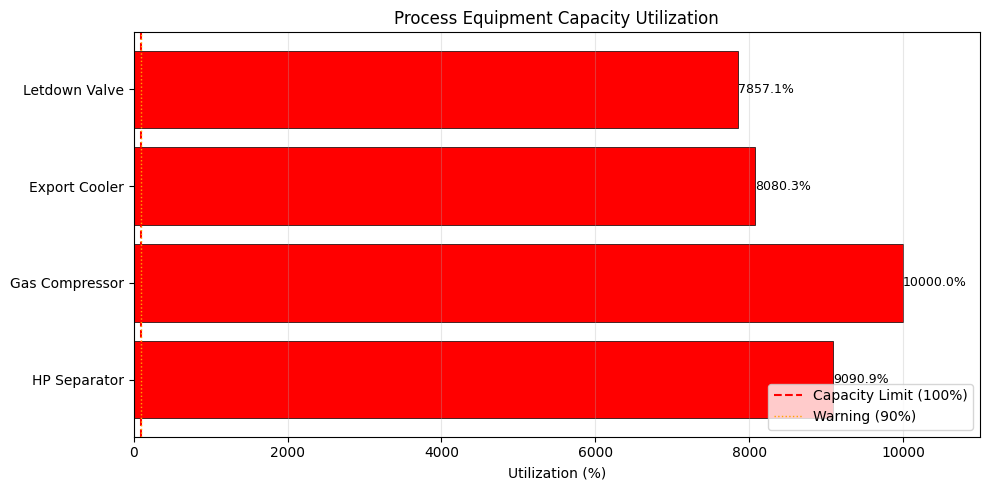

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Collect utilization data for all equipment with constraints
equip_names = []
utilizations = []
colors = []

util_map = process.getCapacityUtilizationSummary()
for name in util_map.keySet():
    u = float(util_map.get(name))  # Already in percentage (0-100)
    equip_names.append(str(name))
    utilizations.append(u)
    if u > 100.0:
        colors.append('red')
    elif u > 90.0:
        colors.append('orange')
    else:
        colors.append('green')

if equip_names:
    fig, ax = plt.subplots(figsize=(10, 5))
    y_pos = np.arange(len(equip_names))
    bars = ax.barh(y_pos, utilizations, color=colors, edgecolor='black', linewidth=0.5)

    # Add threshold lines
    ax.axvline(x=100, color='red', linestyle='--', linewidth=1.5, label='Capacity Limit (100%)')
    ax.axvline(x=90, color='orange', linestyle=':', linewidth=1.0, label='Warning (90%)')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(equip_names)
    ax.set_xlabel('Utilization (%)')
    ax.set_title('Process Equipment Capacity Utilization')
    ax.legend(loc='lower right')
    ax.set_xlim(0, max(max(utilizations) * 1.1, 110))
    ax.grid(axis='x', alpha=0.3)

    # Add value labels on bars
    for bar, val in zip(bars, utilizations):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("No equipment with constraints found.")

## 10. Detailed Constraint Comparison

Plot all constraints across all equipment, showing current vs design vs max values.

In [ ]:
# Collect all constraints across all equipment
all_constraints = []
for equip in [separator, compressor, cooler, valve]:
    constraints = equip.getCapacityConstraints()
    for name in constraints.keySet():
        c = constraints.get(str(name))
        all_constraints.append({
            'equipment': str(equip.getName()),
            'constraint': str(c.getName()),
            'current': float(c.getCurrentValue()),
            'design': float(c.getDesignValue()),
            'max': float(c.getMaxValue()) if c.getMaxValue() < 1e300 else None,
            'utilization': float(c.getUtilization()),
            'type': str(c.getType()),
            'severity': str(c.getSeverity()),
            'unit': str(c.getUnit()),
        })

# Print summary table
print(f"{'Equipment':20s} {'Constraint':20s} {'Current':>10s} {'Design':>10s} {'Max':>10s} {'Util %':>8s} {'Type':>8s} {'Severity':>10s}")
print("-" * 100)
for row in all_constraints:
    max_str = f"{row['max']:.0f}" if row['max'] else "N/A"
    print(f"{row['equipment']:20s} {row['constraint']:20s} "
          f"{row['current']:10.1f} {row['design']:10.0f} {max_str:>10s} "
          f"{row['utilization']*100:7.1f}% {row['type']:>8s} {row['severity']:>10s}")

In [ ]:
# Utilization comparison across all constraints
fig, ax = plt.subplots(figsize=(12, 5))

labels = [f"{r['equipment']}\n{r['constraint']}" for r in all_constraints]
utils = [r['utilization'] * 100 for r in all_constraints]
severity_colors = {
    'CRITICAL': '#d32f2f',
    'HARD': '#f57c00',
    'SOFT': '#fbc02d',
    'ADVISORY': '#4caf50'
}
bar_colors = [severity_colors.get(r['severity'], '#90a4ae') for r in all_constraints]

x_pos = np.arange(len(labels))
bars = ax.bar(x_pos, utils, color=bar_colors, edgecolor='black', linewidth=0.5, width=0.7)

ax.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='Limit (100%)')
ax.axhline(y=90, color='orange', linestyle=':', linewidth=1.0, label='Warning (90%)')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=8, ha='center')
ax.set_ylabel('Utilization (%)')
ax.set_title('Constraint Utilization by Equipment (colored by severity)')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, utils):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

# Legend for severity
patches = [mpatches.Patch(color=c, label=s) for s, c in severity_colors.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0], color='red', linestyle='--', label='Limit'),
                              plt.Line2D([0],[0], color='orange', linestyle=':', label='Warning')],
          loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 11. Increasing Flow — Watch Constraints Respond

A common use case: increase the feed rate and observe how utilization changes.

In [ ]:
# Sweep feed flow rate and track constraint utilization
flow_rates = [30000, 40000, 50000, 55000, 58000]
results = []

for flow in flow_rates:
    feed.setFlowRate(float(flow), "kg/hr")
    process.run()

    row = {'flow_kg_hr': flow}
    for equip in [compressor, separator, cooler, valve]:
        row[str(equip.getName())] = float(equip.getMaxUtilizationPercent())

    bottleneck = process.findBottleneck()
    if bottleneck is not None:
        row['bottleneck'] = str(bottleneck.getEquipmentName())
    else:
        row['bottleneck'] = 'None'
    results.append(row)

# Print results table
equip_list = ['Gas Compressor', 'HP Separator', 'Export Cooler', 'Letdown Valve']
header = f"{'Flow (kg/hr)':>14s}" + "".join(f"{e:>18s}" for e in equip_list) + f"{'Bottleneck':>18s}"
print(header)
print("-" * len(header))
for r in results:
    vals = "".join(f"{r.get(e, 0):17.1f}%" for e in equip_list)
    print(f"{r['flow_kg_hr']:14d}{vals}{r['bottleneck']:>18s}")

# Restore original flow rate
feed.setFlowRate(50000.0, "kg/hr")
process.run()

In [ ]:
# Plot utilization vs flow rate
fig, ax = plt.subplots(figsize=(10, 6))

flows = [r['flow_kg_hr'] for r in results]
for equip_name, color, marker in zip(equip_list,
                                      ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd'],
                                      ['o', 's', '^', 'D']):
    vals = [r.get(equip_name, 0) for r in results]
    ax.plot(flows, vals, marker=marker, label=equip_name, linewidth=2, markersize=8, color=color)

ax.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='Capacity Limit')
ax.axhline(y=90, color='orange', linestyle=':', linewidth=1.0, label='Warning')

ax.set_xlabel('Feed Flow Rate (kg/hr)')
ax.set_ylabel('Max Utilization (%)')
ax.set_title('Equipment Utilization vs Feed Rate')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(120, max(max(r.get(e, 0) for e in equip_list) for r in results) * 1.1))

plt.tight_layout()
plt.show()

## 12. Summary

### Key Takeaways

1. **Universal support**: All 144+ equipment types can have capacity constraints — add them to separators, compressors, coolers, valves, or any custom equipment via `addCapacityConstraint()`

2. **Builder pattern**: Use the fluent API to configure constraints:
   ```python
   CapacityConstraint("name", "unit", ConstraintType.HARD)
       .setDesignValue(5000).setMaxValue(5500)
       .setWarningThreshold(0.9).setSeverity(ConstraintSeverity.CRITICAL)
       .setValueSupplier(lambda: equipment.getValue())
   ```

3. **System-level analysis**: Use `ProcessSystem.findBottleneck()`, `isAnyEquipmentOverloaded()`, and `getCapacityUtilizationSummary()` for system-wide constraint checking

4. **18 built-in strategies**: The `EquipmentCapacityStrategyRegistry` provides pre-configured constraints for all major equipment categories

5. **Enable/disable**: Toggle constraints at individual, equipment, or system level for what-if analysis

6. **Types & severity**: HARD/SOFT/DESIGN constraint types, CRITICAL/HARD/SOFT/ADVISORY severity levels control how violations affect optimization

### Further Reading

- [Capacity Constraint Framework](../docs/process/CAPACITY_CONSTRAINT_FRAMEWORK.md)
- [Optimization and Constraints Guide](../docs/process/optimization/OPTIMIZATION_AND_CONSTRAINTS.md)
- [Optimization Overview](../docs/process/optimization/OPTIMIZATION_OVERVIEW.md)